# Data Preparation

## Imports

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.oaxaca import OaxacaBlinder
import numpy as np
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap
import warnings
warnings.filterwarnings("ignore")


## Import Dataset

In [26]:
#Import dataset present on ./data

dt_std_pt = pd.read_csv('./data/students_portugal.csv', sep=';')

#Show the first 5 rows of the dataset
dt_std_pt.head()

,CNTSTUID,CNTSCHID,STRATUM,STU_GENDER,ISCEDP,REPEAT,EXERPRAC,RELATST,BULLIED,FAMSUP,...,PV1CRTH_NC,PV2CRTH_NC,PV3CRTH_NC,PV4CRTH_NC,PV5CRTH_NC,PV6CRTH_NC,PV7CRTH_NC,PV8CRTH_NC,PV9CRTH_NC,PV10CRTH_NC
0,62050001.0,62000159.0,PRT15,1.0,244.0,1.0,6.0,0.1469,1.1953,0.0332,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,62050002.0,62000170.0,PRT09,2.0,344.0,0.0,5.0,0.2898,-1.2280,-0.2763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,62050003.0,62000004.0,PRT07,1.0,244.0,1.0,2.0,-0.5679,0.6699,1.7153,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,62050005.0,62000044.0,PRT10,1.0,344.0,0.0,1.0,2.2513,-1.2280,-0.6200,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,62050007.0,62000001.0,PRT08,2.0,344.0,0.0,10.0,2.9152,0.1107,-0.0578,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Ver cenas importantes

In [27]:
# ver estudantes duplicados
count = dt_std_pt[dt_std_pt.duplicated(keep=False)].shape[0]
count

0

In [28]:
# ver nulos
dt_std_pt.isnull().sum()
# mostrar todas as colunas com nulos
count = dt_std_pt.isnull().sum()[dt_std_pt.isnull().sum() > 0]
print(f"Nº de colunas com nulos: {count.shape[0]}")

Nº de colunas com nulos: 40


In [29]:
#nº de colunas com +50% de nulos
count = dt_std_pt.isnull().sum()[dt_std_pt.isnull().sum() > (dt_std_pt.shape[0] * 0.33)]    # 1/3 de nulos
print(f"Nº de colunas com +33% de nulos: {count.shape[0]}")
count

Nº de colunas com +33% de nulos: 20


PV1FLIT        6793
PV2FLIT        6793
PV3FLIT        6793
PV4FLIT        6793
PV5FLIT        6793
PV6FLIT        6793
PV7FLIT        6793
PV8FLIT        6793
PV9FLIT        6793
PV10FLIT       6793
PV1CRTH_NC     4075
PV2CRTH_NC     4075
PV3CRTH_NC     4075
PV4CRTH_NC     4075
PV5CRTH_NC     4075
PV6CRTH_NC     4075
PV7CRTH_NC     4075
PV8CRTH_NC     4075
PV9CRTH_NC     4075
PV10CRTH_NC    4075
dtype: int64

<Axes: >

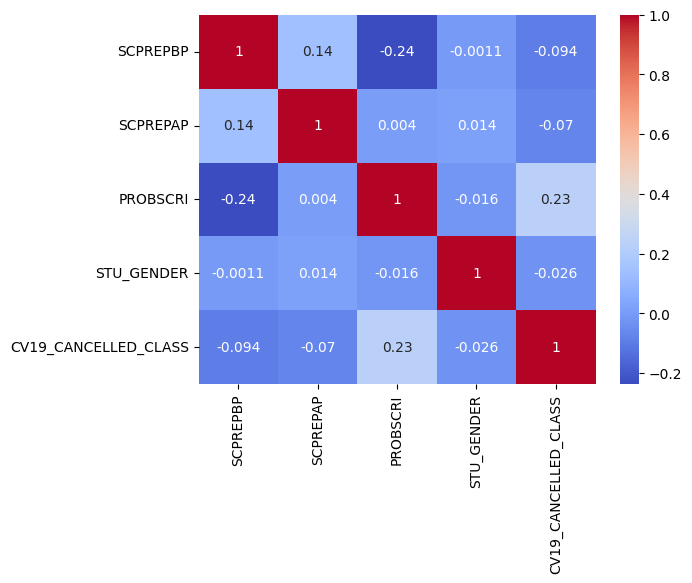

In [30]:
# correlação entre GRADE,ESCS e HISCED com spearman

sns.heatmap(dt_std_pt[["SCPREPBP", "SCPREPAP", "PROBSCRI", "STU_GENDER", "CV19_CANCELLED_CLASS"]].corr(method='spearman'), annot=True, cmap="coolwarm")

In [33]:
# correlação entre idade do prof e anos de experiência com spearman
cols_modelo = [
    'STU_GENDER', 'ISCEDP', 'REPEAT',
    'EXERPRAC', 'RELATST', 'BULLIED', 'FAMSUP', 'HISCED', 'ICTRES', 'ESCS',
    'SCHLTYPE', 'SCHSIZE', 'TOTAT', 'PROATCE', 'STRATIO', 'STAFFSHORT',
    'EDUSHORT', 'SCPREPBP', 'SCPREPAP', 'PROBSCRI', 'CV19_ONLINE_CLASS',
    'CV19_CANCELLED_CLASS', 'TC_GENDER_MEAN', 'TC_AGE_MEAN', 'TC_EXP_MEAN',
    'TC_PERM_PERC'
]

dt_std_pt[cols_modelo].corr(method='spearman')

,STU_GENDER,ISCEDP,REPEAT,EXERPRAC,RELATST,BULLIED,FAMSUP,HISCED,ICTRES,ESCS,...,EDUSHORT,SCPREPBP,SCPREPAP,PROBSCRI,CV19_ONLINE_CLASS,CV19_CANCELLED_CLASS,TC_GENDER_MEAN,TC_AGE_MEAN,TC_EXP_MEAN,TC_PERM_PERC
STU_GENDER,1.000000,0.024339,0.077427,0.266243,-0.022696,0.011601,-0.097793,0.019043,0.027933,0.002612,...,-0.015309,-0.001065,0.014454,-0.016127,0.007640,-0.026100,0.002146,-0.015974,-0.017953,0.019689
ISCEDP,0.024339,1.000000,-0.656108,-0.045536,0.025656,-0.097289,0.026678,0.001447,0.095331,0.071473,...,-0.101270,0.045391,-0.033905,-0.185494,0.015977,-0.004461,0.045679,-0.079531,-0.078876,-0.038414
REPEAT,0.077427,-0.656108,1.000000,0.094433,-0.050853,0.133723,-0.081393,-0.152496,-0.133962,-0.255356,...,0.087255,-0.006368,0.036442,0.122212,-0.000740,0.008465,0.028561,-0.041879,-0.053664,-0.041255
EXERPRAC,0.266243,-0.045536,0.094433,1.000000,-0.035593,0.017410,0.041526,0.070138,0.095079,0.063887,...,-0.007816,-0.010049,0.015224,-0.002988,0.019526,-0.033532,0.014225,-0.019634,-0.017226,-0.007270
RELATST,-0.022696,0.025656,-0.050853,-0.035593,1.000000,-0.200440,0.202241,-0.007237,0.006590,0.012182,...,-0.039875,0.020326,0.022333,-0.062578,0.018258,-0.013284,0.035396,-0.066039,-0.046606,0.008441
BULLIED,0.011601,-0.097289,0.133723,0.017410,-0.200440,1.000000,-0.155608,0.030305,-0.038051,-0.007991,...,0.009063,-0.005263,-0.001672,0.039903,0.005579,0.003996,0.010801,-0.021313,-0.038966,-0.001146
FAMSUP,-0.097793,0.026678,-0.081393,0.041526,0.202241,-0.155608,1.000000,0.018291,0.082625,0.061039,...,0.011082,0.007607,0.012895,0.027050,0.011615,0.016191,-0.008548,0.021311,0.040821,0.021292
HISCED,0.019043,0.001447,-0.152496,0.070138,-0.007237,0.030305,0.018291,1.000000,0.238055,0.830074,...,-0.025969,0.002124,-0.045123,-0.074272,0.042422,-0.036492,-0.005252,0.014898,-0.008243,0.039547
ICTRES,0.027933,0.095331,-0.133962,0.095079,0.006590,-0.038051,0.082625,0.238055,1.000000,0.477295,...,-0.035643,0.014917,0.007988,-0.072443,0.034792,-0.026987,-0.023900,0.012167,0.030965,0.046460
ESCS,0.002612,0.071473,-0.255356,0.063887,0.012182,-0.007991,0.061039,0.830074,0.477295,1.000000,...,-0.045742,0.019623,-0.052101,-0.108975,0.044376,-0.031401,-0.011983,0.026535,0.016923,0.063089


## Preparar dataset

### Preparar para Oaxaca-Blinder

In [ ]:
dt_std_pt.drop(columns=["TC_EXP_MEAN", "ISCEDP", "HISCED"], inplace=True)

In [9]:
mapa_regioes_prt = {
    'PRT01': 'Alentejo Central', 'PRT02': 'Alentejo Litoral', 'PRT03': 'Algarve',
    'PRT04': 'Alto Alentejo', 'PRT05': 'Alto Minho', 'PRT06': 'Alto Tâmega',
    'PRT07': 'AM Lisboa', 'PRT08': 'AM Porto', 'PRT09': 'Ave',
    'PRT10': 'Baixo Alentejo', 'PRT11': 'Beira Baixa', 'PRT12': 'Beiras e Serra da Estrela',
    'PRT13': 'Cávado', 'PRT14': 'Douro', 'PRT15': 'Lezíria do Tejo',
    'PRT16': 'Médio Tejo', 'PRT17': 'Oeste', 'PRT18': 'R.A. Madeira',
    'PRT19': 'R.A. Açores', 'PRT20': 'Região de Aveiro', 'PRT21': 'Região de Coimbra',
    'PRT22': 'Região de Leiria', 'PRT23': 'Tâmega e Sousa', 'PRT24': 'Terras de Trás-os-Montes',
    'PRT25': 'Viseu Dão Lafões'
}

dt_std_pt["STRATUM"] = dt_std_pt["STRATUM"].map(mapa_regioes_prt)

In [10]:
mapa_macro = {
    # Norte
    'Alto Minho': 'Norte',
    'Cávado': 'Norte',
    'Ave': 'Norte',
    'Tâmega e Sousa': 'Norte',
    'Douro': 'Norte',
    'Terras de Trás-os-Montes': 'Norte',
    'Alto Tâmega': 'Norte',

    # Centro
    'Região de Aveiro': 'Centro',
    'Região de Coimbra': 'Centro',
    'Região de Leiria': 'Centro',
    'Viseu Dão Lafões': 'Centro',
    'Beira Baixa': 'Centro',
    'Beiras e Serra da Estrela': 'Centro',
    'Oeste': 'Centro',
    'Médio Tejo': 'Centro',

    # Lisboa
    'AM Lisboa': 'Lisboa',
    'Lezíria do Tejo': 'Lisboa',

    # Sul (Alentejo+Algarve)
    'Alto Alentejo': 'Sul',
    'Alentejo Central': 'Sul',
    'Alentejo Litoral': 'Sul',
    'Baixo Alentejo': 'Sul',
    'Algarve': 'Sul',
    
    # Porto (separado)
    'AM Porto': 'Porto',

    # Algarve
    #'Algarve': 'Algarve',

    # Ilhas
    'R.A. Madeira': 'Ilhas',
    'R.A. Açores': 'Ilhas'
}

dt_std_pt["REGIAO"] = dt_std_pt["STRATUM"].map(mapa_macro)


In [11]:
df = dt_std_pt.copy()

group_col = "REGIAO"

# caso se queira comparar apenas pares de regiões
region_A = "Porto"
region_B = "Lisboa"

pv_cols = [f"PV{i}MATH" for i in range(1, 11)]

X_base = [  'ST004D01T', 'REPEAT', 'EXERPRAC', 'RELATST',
            'BULLIED', 'FAMSUP',  'ICTRES', 'ESCS',
            'SCHLTYPE', 'SCHSIZE', 'TOTAT', 'PROATCE', 'STRATIO',
            'STAFFSHORT', 'EDUSHORT', 'SCPREPBP', 'SCPREPAP', 'PROBSCRI',
            'SC214Q01JA', 'SC214Q03JA',
            'TC_GENERO_MEDIA', 'TC_IDADE_MEDIA', 'TC_PERM_PERC'

]

# filtrar regiões
df = df[df[group_col].isin([region_A, region_B])]

# recodificação manual — sem get_dummies
df["female"] = (df["ST004D01T"] == 1).astype(int)

dummy_cols = ["female"]

X_cols = X_base + dummy_cols

# criar grupo binário
df["group_bin"] = (df[group_col] == region_B).astype(int)

# limpar NA
df_model = df.dropna(subset=X_cols + pv_cols + [group_col]).copy()

### Preparar para clustering

In [21]:
# features para o clustering
features = [
    # contexto aluno
    "ESCS", "ICTRES", "HISCED",
    # comportamento
    "BULLIED", "REPEAT", "EXERPRAC", "RELATST", "FAMSUP",
    # escola
    "SCHSIZE", "STRATIO", "STAFFSHORT", "EDUSHORT",
    "PROATCE", "SCPREPBP", "SCPREPAP", "PROBSCRI",
    # professores
    "TC_IDADE_MEDIA", "TC_EXP_MEDIA", "TC_PERM_PERC",
]

# filtrar só colunas que existem no df
features = [f for f in features if f in dt_std_pt.columns]

outcome = "PV_MATH"

regioes = dt_std_pt["REGIAO"].dropna().unique()
pares   = [(a, b) for i, a in enumerate(regioes) for b in regioes[i+1:]]

resultados_detail = []

for region_A, region_B in pares:

    df_A = dt_std_pt[dt_std_pt["REGIAO"] == region_A][features + [outcome]].dropna()
    df_B = dt_std_pt[dt_std_pt["REGIAO"] == region_B][features + [outcome]].dropna()

    if len(df_A) < 30 or len(df_B) < 30:
        continue

    # regressão em cada grupo
    reg_A = LinearRegression().fit(df_A[features], df_A[outcome])
    reg_B = LinearRegression().fit(df_B[features], df_B[outcome])

    # médias das features
    mean_A = df_A[features].mean()
    mean_B = df_B[features].mean()

    # gap total
    gap = df_A[outcome].mean() - df_B[outcome].mean()

    # contribuição de cada variável à componente explicada
    # usando coeficientes de B aplicados à diferença de médias
    contrib = {}
    for feat in features:
        contrib[feat] = reg_B.coef_[features.index(feat)] * (mean_A[feat] - mean_B[feat])

    explained   = sum(contrib.values())
    unexplained = gap - explained

    row = {
        "par":         f"{region_A} → {region_B}",
        "region_A":    region_A,
        "region_B":    region_B,
        "gap_total":   round(gap, 2),
        "explained":   round(explained, 2),
        "unexplained": round(unexplained, 2),
    }
    for feat in features:
        row[f"contrib_{feat}"] = round(contrib[feat], 4)

    resultados_detail.append(row)

df_ob = pd.DataFrame(resultados_detail)
print(f"Pares calculados: {len(df_ob)}")
print(df_ob[["par", "gap_total", "explained", "unexplained"]].to_string())



Pares calculados: 15
                par  gap_total  explained  unexplained
0    Lisboa → Norte      13.08      10.88         2.20
1      Lisboa → Sul      16.85      23.22        -6.36
2    Lisboa → Porto      -0.44       6.05        -6.49
3   Lisboa → Centro      -6.31      11.05       -17.37
4    Lisboa → Ilhas      14.90      47.78       -32.87
5       Norte → Sul       3.77       2.98         0.79
6     Norte → Porto     -13.52      -5.43        -8.09
7    Norte → Centro     -19.39      -8.68       -10.72
8     Norte → Ilhas       1.82      31.34       -29.52
9       Sul → Porto     -17.29     -10.67        -6.62
10     Sul → Centro     -23.17      -6.07       -17.10
11      Sul → Ilhas      -1.95      21.00       -22.95
12   Porto → Centro      -5.87       3.85        -9.73
13    Porto → Ilhas      15.34      48.92       -33.58
14   Centro → Ilhas      21.22      19.15         2.07


## Modeling (Oaxaca-Blinder)

### Par

In [13]:
explained_list = []
unexplained_list = []

for pv in pv_cols:
    
    X = df_model[X_cols + ["group_bin"]].apply(pd.to_numeric, errors="coerce").astype(float)
    X = sm.add_constant(X)  # adiciona constante

    y = df_model[pv].astype(float)

    mask = X.notna().all(axis=1) & y.notna()

    X = X[mask]
    y = y[mask]
    
    model = OaxacaBlinder(y, X, bifurcate="group_bin", hasconst=True)
    res = model.two_fold()
    
    explained, unexplained, gap = res.params  # desempacotar a tuple
    
    explained_list.append(explained)
    unexplained_list.append(unexplained)

explained_mean = np.mean(explained_list)
unexplained_mean = np.mean(unexplained_list)

print("Explained (média):", explained_mean)
print("Unexplained (média):", unexplained_mean)
print("Diferença total:", explained_mean + unexplained_mean)

Explained (média): 1.1510060453678246
Unexplained (média): -0.26221487046138225
Diferença total: 0.8887911749064423


### Geral

In [14]:
from itertools import combinations

regioes = dt_std_pt[group_col].unique()
pares = list(combinations(regioes, 2))

resultados = []

for region_A, region_B in pares:
    
    df_par = dt_std_pt.copy()
    df_par = df_par[df_par[group_col].isin([region_A, region_B])]
    
    df_par["female"] = (df_par["ST004D01T"] == 1).astype(int)

    df_par["group_bin"] = (df_par[group_col] == region_B).astype(int)
    df_par = df_par.dropna(subset=X_cols + pv_cols + [group_col]).copy()
    
    explained_list = []
    unexplained_list = []
    
    for pv in pv_cols:
        X = df_par[X_cols + ["group_bin"]].apply(pd.to_numeric, errors="coerce").astype(float)
        X = sm.add_constant(X)
        y = df_par[pv].astype(float)
        
        mask = X.notna().all(axis=1) & y.notna()
        X = X[mask]
        y = y[mask]
        
        model = OaxacaBlinder(y, X, bifurcate="group_bin", hasconst=True)
        res = model.two_fold()
        explained, unexplained, gap = res.params
        
        explained_list.append(explained)
        unexplained_list.append(unexplained)
    
    resultados.append({
        "Região A": region_A,
        "Região B": region_B,
        "Explained": round(np.mean(explained_list), 3),
        "Unexplained": round(np.mean(unexplained_list), 3),
        "Gap total": round(np.mean(explained_list) + np.mean(unexplained_list), 3)
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

   Região A Região B  Explained  Unexplained  Gap total
0    Lisboa    Norte     -4.363       17.443     13.080
1    Lisboa      Sul     -0.877       17.731     16.854
2    Lisboa    Porto      1.151       -0.262      0.889
3    Lisboa   Centro      6.063        0.252      6.314
4    Lisboa    Ilhas    -15.951       30.852     14.901
5     Norte      Sul      2.645        1.129      3.774
6     Norte    Porto      3.767        9.752     13.520
7     Norte   Centro     10.580        8.814     19.395
8     Norte    Ilhas     -5.225        7.053      1.828
9       Sul    Porto      5.344       11.950     17.293
10      Sul   Centro     14.091        9.078     23.168
11      Sul    Ilhas     27.369      -25.314      2.055
12    Porto   Centro      8.391       -2.516      5.875
13    Porto    Ilhas     -1.471       16.811     15.340
14   Centro    Ilhas     30.687       -9.472     21.215


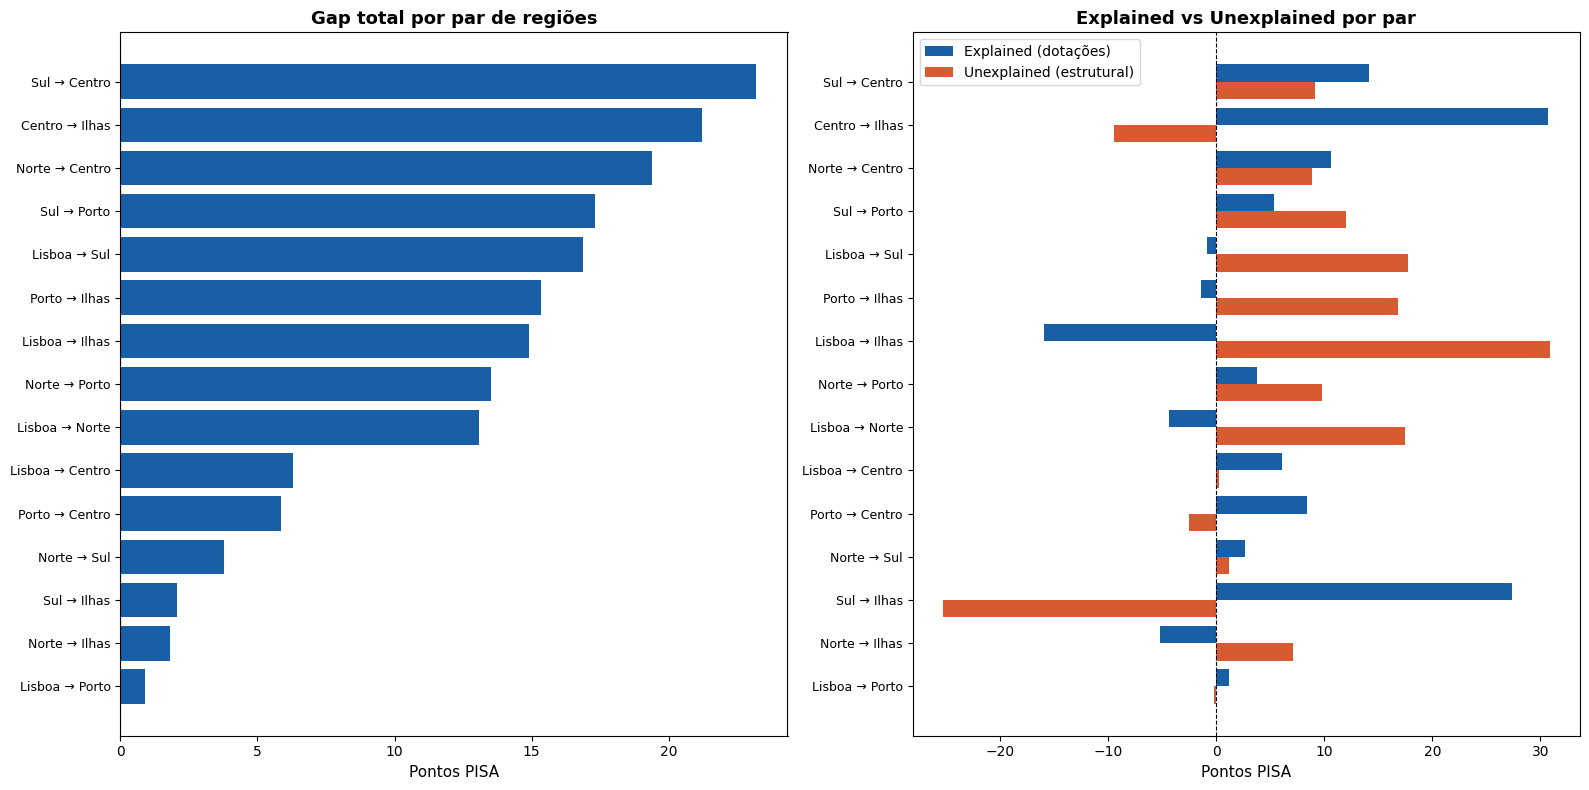

In [15]:
df_res = df_resultados.copy()
df_res["Par"] = df_res["Região A"] + " → " + df_res["Região B"]
df_res = df_res.sort_values("Gap total", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- gráfico 1: gap total ---
cores_gap = ["#185FA5" if g >= 0 else "#A32D2D" for g in df_res["Gap total"]]
axes[0].barh(df_res["Par"], df_res["Gap total"], color=cores_gap)
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("Pontos PISA", fontsize=11)
axes[0].set_title("Gap total por par de regiões", fontsize=13, fontweight="bold")
axes[0].tick_params(axis="y", labelsize=9)

# --- gráfico 2: explained vs unexplained ---
y = np.arange(len(df_res))
height = 0.4

axes[1].barh(y + height/2, df_res["Explained"], height=height, color="#185FA5", label="Explained (dotações)")
axes[1].barh(y - height/2, df_res["Unexplained"], height=height, color="#D85A30", label="Unexplained (estrutural)")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_yticks(y)
axes[1].set_yticklabels(df_res["Par"], fontsize=9)
axes[1].set_xlabel("Pontos PISA", fontsize=11)
axes[1].set_title("Explained vs Unexplained por par", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("oaxaca_resultados.png", dpi=150, bbox_inches="tight")
plt.show()

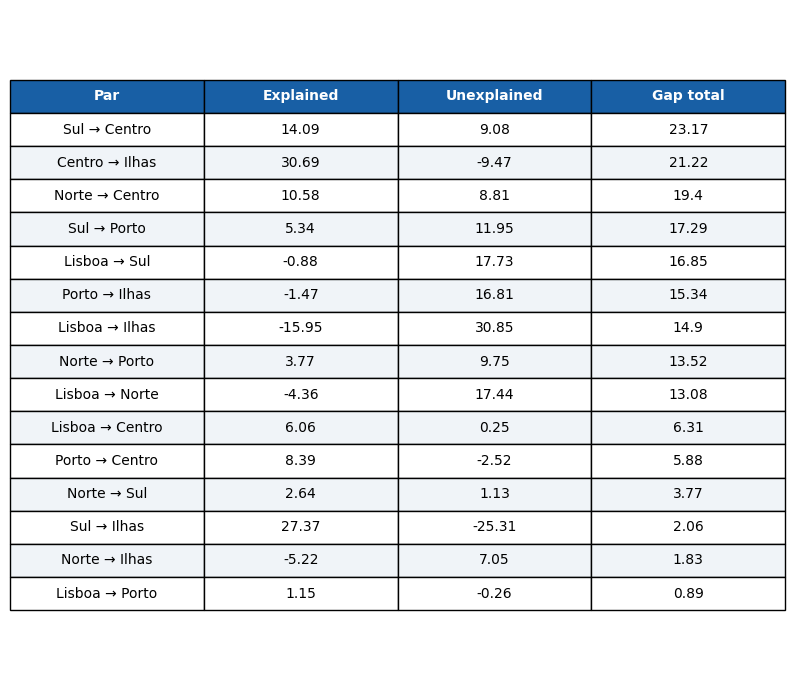

In [16]:
fig2, ax = plt.subplots(figsize=(8, 7))
ax.axis("off")

df_tabela = df_resultados.copy()
df_tabela["Par"] = df_tabela["Região A"] + " → " + df_tabela["Região B"]
df_tabela = df_tabela.sort_values("Gap total", ascending=False)[["Par", "Explained", "Unexplained", "Gap total"]]
df_tabela[["Explained", "Unexplained", "Gap total"]] = df_tabela[["Explained", "Unexplained", "Gap total"]].round(2)

tabela = ax.table(
    cellText=df_tabela.values,
    colLabels=["Par", "Explained", "Unexplained", "Gap total"],
    cellLoc="center",
    loc="center"
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.6)

# cabeçalho
for j in range(4):
    tabela[0, j].set_facecolor("#185FA5")
    tabela[0, j].set_text_props(color="white", fontweight="bold")

# linhas alternadas
for i in range(1, len(df_tabela) + 1):
    for j in range(4):
        tabela[i, j].set_facecolor("#f0f4f8" if i % 2 == 0 else "white")

plt.tight_layout()
plt.savefig("oaxaca_tabela.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
resultados_detail = []

for region_A, region_B in pares:
    
    df_par = dt_std_pt.copy()
    df_par = df_par[df_par[group_col].isin([region_A, region_B])]
    df_par["female"] = (df_par["ST004D01T"] == 1).astype(int)
    df_par["group_bin"] = (df_par[group_col] == region_B).astype(int)
    df_par = df_par.dropna(subset=X_cols + pv_cols + [group_col]).copy()

    detail_explained   = None
    detail_unexplained = None

    for pv in pv_cols:
        df_clean = df_par[X_cols + ["group_bin", pv]].apply(pd.to_numeric, errors="coerce").dropna()

        X = sm.add_constant(df_clean[X_cols])
        y = df_clean[pv]
        group = df_clean["group_bin"]

        # separar os dois grupos
        X_A = X[group == 0]
        y_A = y[group == 0]
        X_B = X[group == 1]
        y_B = y[group == 1]

        # regressão separada para cada grupo
        coef_A = sm.OLS(y_A, X_A).fit().params
        coef_B = sm.OLS(y_B, X_B).fit().params

        # médias das características
        mean_A = X_A.mean()
        mean_B = X_B.mean()

        # decomposição detalhada
        explained   = (mean_A - mean_B) * coef_B
        unexplained = mean_B * (coef_A - coef_B)

        if detail_explained is None:
            detail_explained   = explained
            detail_unexplained = unexplained
        else:
            detail_explained   += explained
            detail_unexplained += unexplained

    detail_explained   /= len(pv_cols)
    detail_unexplained /= len(pv_cols)

    for var in detail_explained.index:
        resultados_detail.append({
            "Região A":    region_A,
            "Região B":    region_B,
            "Variável":    var,
            "Explained":   round(detail_explained[var], 3),
            "Unexplained": round(detail_unexplained[var], 3),
        })

df_detail = pd.DataFrame(resultados_detail)

# ranking médio entre todos os pares
resumo = (df_detail.groupby("Variável")[["Explained","Unexplained"]]
                   .mean()
                   .abs()
                   .sort_values("Explained", ascending=False))
print(resumo)

                 Explained  Unexplained
Variável                               
STRATIO          14.851667    18.969733
SC214Q03JA        7.251533     0.985467
TC_IDADE_MEDIA    6.208600    68.692800
TOTAT             5.794267    53.498733
SCHSIZE           2.130133    13.100733
SCPREPAP          1.492667     3.338800
PROBSCRI          1.367333     0.652867
ESCS              1.351867     0.666467
SC214Q01JA        1.054533    34.937267
female            1.044133    23.710867
STAFFSHORT        0.926000     0.639600
SCHLTYPE          0.836667    24.379600
ST004D01T         0.813933    66.140800
PROATCE           0.787933     0.020067
REPEAT            0.732333     0.401400
TC_PERM_PERC      0.607667     4.610733
EDUSHORT          0.570267     2.068533
SCPREPBP          0.471067     0.777000
RELATST           0.376800     0.338800
ICTRES            0.374667     0.116467
EXERPRAC          0.282667     3.703800
TC_GENERO_MEDIA   0.185267    24.261067
FAMSUP            0.084400     0.122133


## Modeling - CLustering

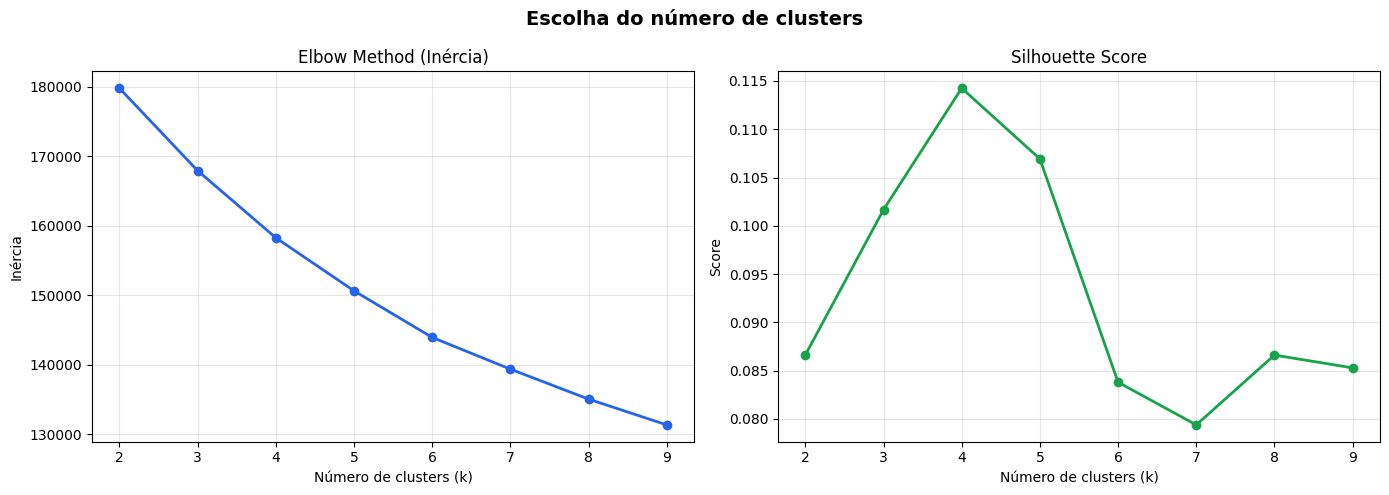


Melhor k pelo Silhouette: 4

Distribuição dos clusters:
cluster
0    2886
1    1610
2    6245
3     127
Name: count, dtype: int64


In [18]:
# 3. ESCOLHA DO NÚMERO DE CLUSTERS (Elbow + Silhouette)

inertias    = []
silhouettes = []
k_range     = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Escolha do número de clusters", fontsize=14, fontweight="bold")

axes[0].plot(k_range, inertias, "o-", color="#2563eb", linewidth=2)
axes[0].set_title("Elbow Method (Inércia)")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inércia")
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouettes, "o-", color="#16a34a", linewidth=2)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_escolha_k.png", dpi=150, bbox_inches="tight")
plt.show()

# escolhe o k com melhor silhouette
best_k = k_range[np.argmax(silhouettes)]
print(f"\nMelhor k pelo Silhouette: {best_k}")


# ============================================================
# 4. MODELO FINAL
# ============================================================

# ajusta o k aqui se quiseres forçar um valor específico
K_FINAL = best_k

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_cluster["cluster"] = km_final.fit_predict(X_scaled)

print(f"\nDistribuição dos clusters:")
print(df_cluster["cluster"].value_counts().sort_index())



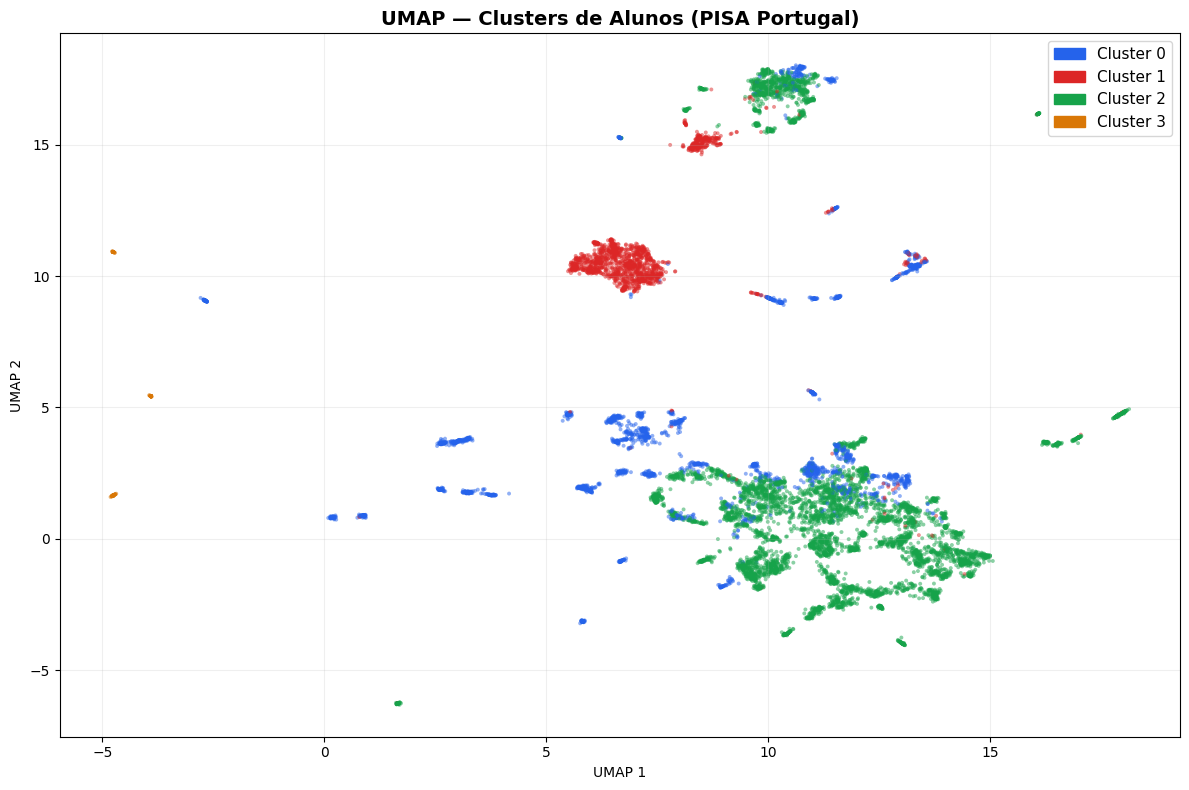

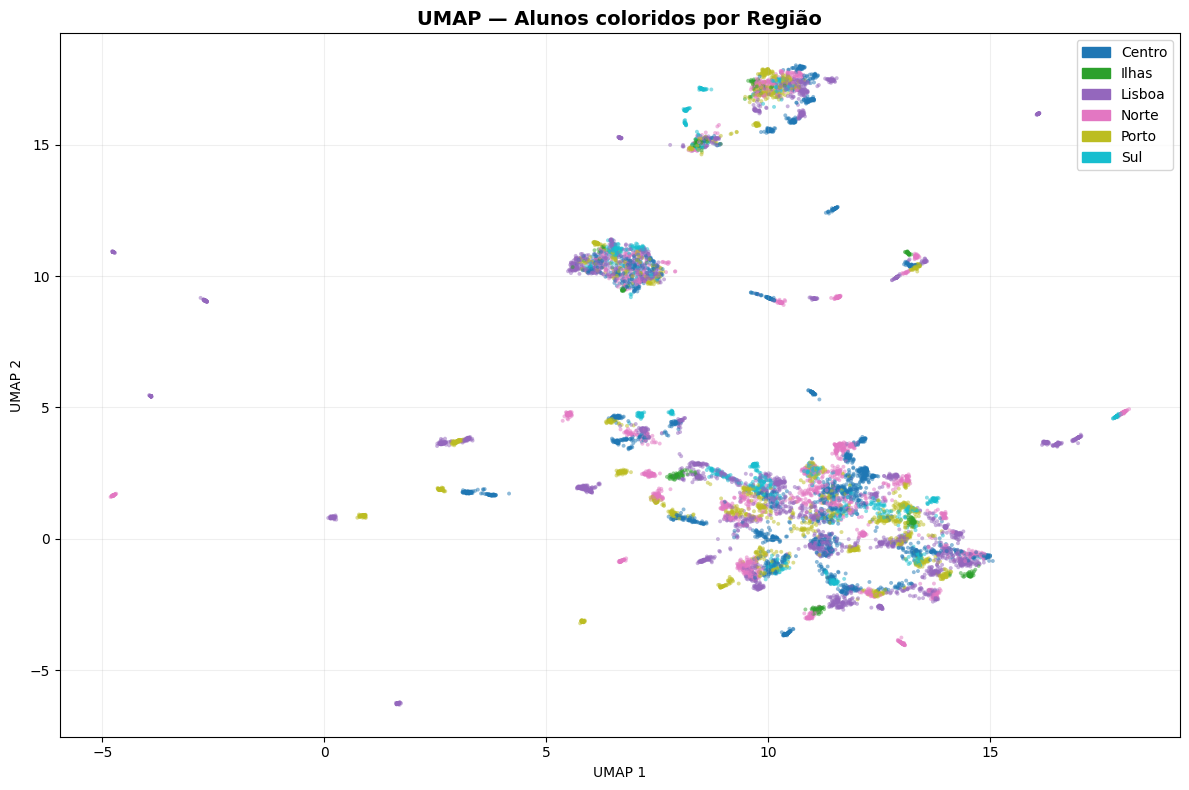

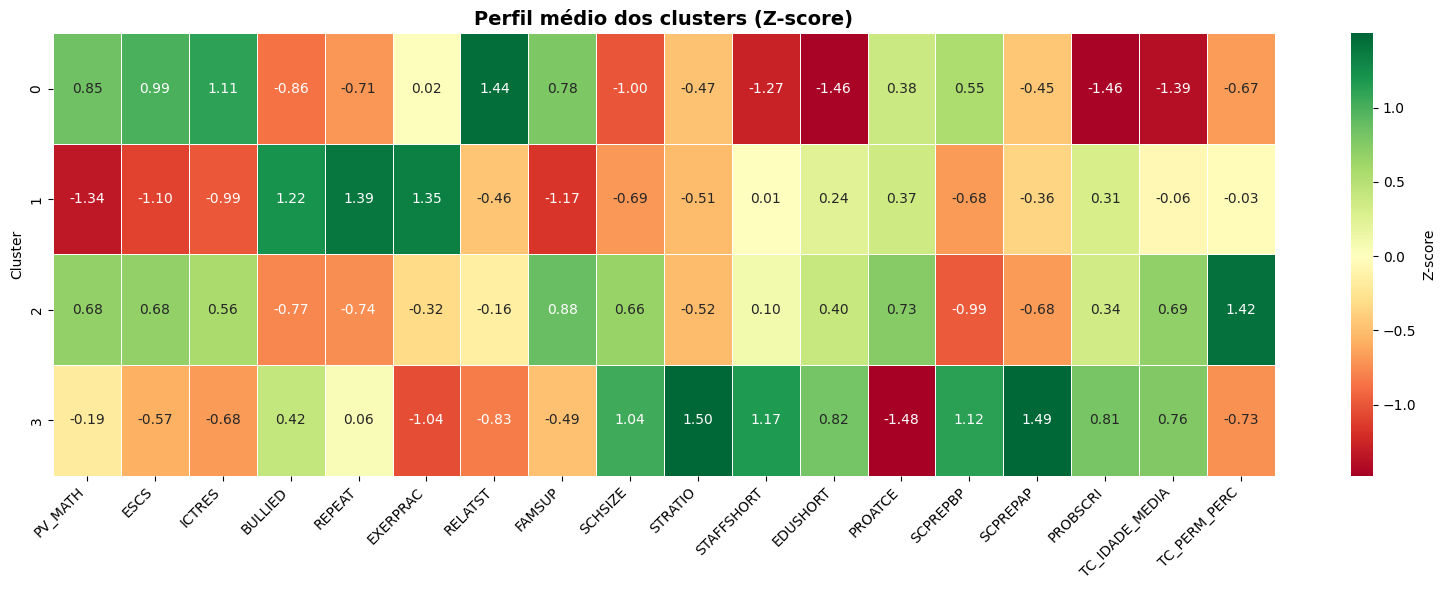

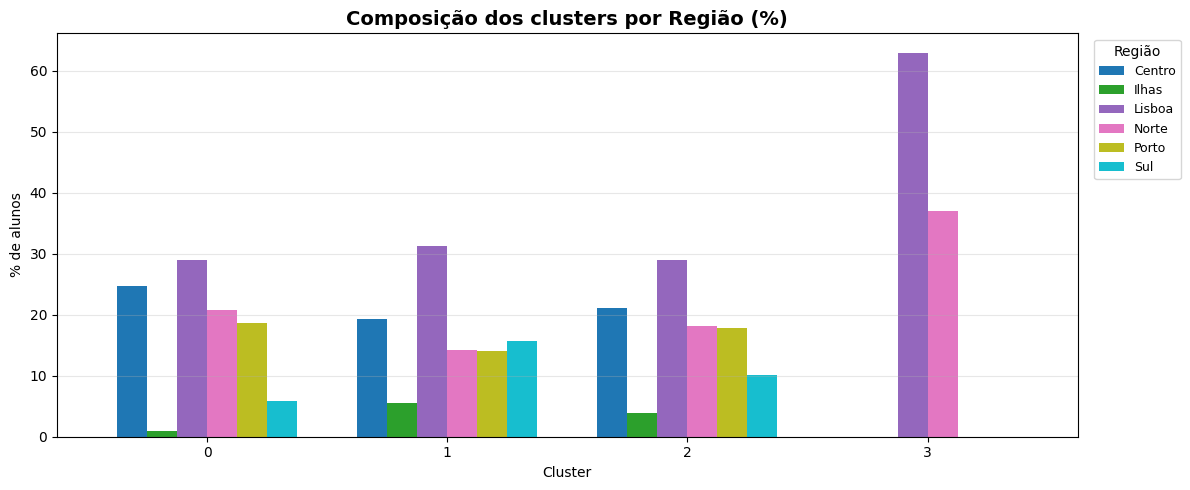

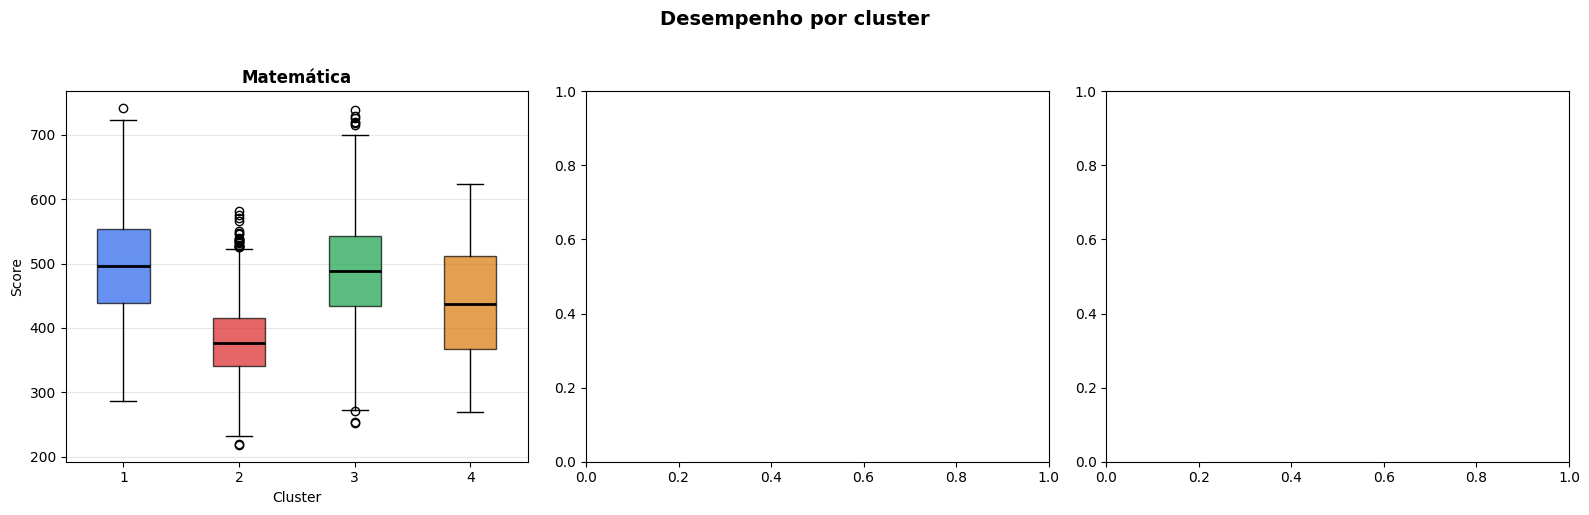


=== RESUMO DOS CLUSTERS ===

         PV_MATH  ESCS  ICTRES  BULLIED  REPEAT  EXERPRAC  RELATST  FAMSUP  SCHSIZE  STRATIO  STAFFSHORT  EDUSHORT  PROATCE  SCPREPBP  SCPREPAP  PROBSCRI  TC_IDADE_MEDIA  TC_PERM_PERC  n_alunos
cluster                                                                                                                                                                                          
0         497.82  0.03    0.10    -0.64    0.01      4.53     0.45    0.46  1307.64    10.84        0.14     -0.47     0.79      0.32      0.29     -0.42           48.00          0.70      2886
1         380.30 -0.94   -0.34    -0.23    0.98      5.40     0.14    0.18  1406.96     9.20        1.02      0.43     0.79     -0.25      0.32      0.54           50.78          0.72      1610
2         488.84 -0.12   -0.02    -0.62    0.00      4.31     0.18    0.48  1839.08     9.11        1.08      0.51     0.82     -0.39      0.23      0.55           52.35          0.76      6245


In [19]:
# 5. UMAP - REDUÇÃO PARA 2D
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    random_state=42,
    verbose=False
)

embedding = reducer.fit_transform(X_scaled)

df_cluster["UMAP1"] = embedding[:, 0]
df_cluster["UMAP2"] = embedding[:, 1]


# 6. GRÁFICOS
PALETTE = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#be185d"]
colors   = [PALETTE[c] for c in df_cluster["cluster"]]

# --- 6.1 UMAP por cluster ---
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    df_cluster["UMAP1"], df_cluster["UMAP2"],
    c=colors, alpha=0.5, s=8, linewidths=0
)
patches = [mpatches.Patch(color=PALETTE[i], label=f"Cluster {i}") for i in range(K_FINAL)]
ax.legend(handles=patches, fontsize=11, loc="best")
ax.set_title("UMAP — Clusters de Alunos (PISA Portugal)", fontsize=14, fontweight="bold")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("umap_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


# --- 6.2 UMAP por região ---
regioes = df_cluster["REGIAO"].astype("category")
reg_codes = regioes.cat.codes
reg_cats  = regioes.cat.categories

cmap_reg = plt.cm.get_cmap("tab10", len(reg_cats))

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    df_cluster["UMAP1"], df_cluster["UMAP2"],
    c=reg_codes, cmap=cmap_reg, alpha=0.5, s=8, linewidths=0
)
patches_reg = [mpatches.Patch(color=cmap_reg(i), label=r) for i, r in enumerate(reg_cats)]
ax.legend(handles=patches_reg, fontsize=10, loc="best")
ax.set_title("UMAP — Alunos coloridos por Região", fontsize=14, fontweight="bold")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("umap_regioes.png", dpi=150, bbox_inches="tight")
plt.show()


# --- 6.3 Perfil médio dos clusters (heatmap) ---
perfil = df_cluster.groupby("cluster")[features].mean()
perfil_norm = (perfil - perfil.mean()) / perfil.std()  # z-score para comparar escalas

fig, ax = plt.subplots(figsize=(16, K_FINAL + 2))
sns.heatmap(
    perfil_norm,
    annot=True, fmt=".2f", cmap="RdYlGn",
    linewidths=0.5, ax=ax, center=0,
    cbar_kws={"label": "Z-score"}
)
ax.set_title("Perfil médio dos clusters (Z-score)", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Cluster")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("cluster_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# --- 6.4 Composição dos clusters por região ---
cross = pd.crosstab(
    df_cluster["cluster"],
    df_cluster["REGIAO"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(12, 5))
cross.plot(kind="bar", ax=ax, colormap="tab10", width=0.75)
ax.set_title("Composição dos clusters por Região (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("% de alunos")
ax.legend(title="Região", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cluster_por_regiao.png", dpi=150, bbox_inches="tight")
plt.show()


# --- 6.5 Boxplots de desempenho por cluster ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
dominios = {"Matemática": "PV_MATH"}

for ax, (titulo, col) in zip(axes, dominios.items()):
    data = [df_cluster[df_cluster["cluster"] == k][col].dropna() for k in range(K_FINAL)]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], PALETTE[:K_FINAL]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Desempenho por cluster", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("cluster_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# 7. RESUMO FINAL
# ============================================================

print("\n=== RESUMO DOS CLUSTERS ===\n")
resumo = df_cluster.groupby("cluster")[features + ["REGIAO"]].agg(
    {**{f: "mean" for f in features}, "REGIAO": "count"}
).rename(columns={"REGIAO": "n_alunos"})

print(resumo.round(2).to_string())